# Function 6 — 5D Cake Recipe Optimisation

**Objective:** maximise Y. All values are negative by design, so maximising
brings the score as close to zero as possible.
**Surrogate:** GP with Matérn 5/2 kernel
**Acquisition:** Expected Improvement (EI), ξ = 0.01 — tight exploitation
**Y transform:** none

---

Five ingredient quantities in [0, 1] — flour, sugar, eggs, butter, milk —
scored by expert tasters. One query per week, five rounds completed.

## Problem characteristics

| Property | Value | Implication |
|---|---|---|
| Dimensions | 5D | A GP is still workable, but the space is getting large |
| Dataset | 20 supplied, 25 total | Thin for five dimensions |
| Y range | −2.66 to −0.32 | Compact, roughly 3.7× — no transform needed |
| Objective | Maximise (bring score toward zero) | Find the best recipe |
| Surface | Not described as multimodal | No reason to push exploration hard |
| Noise | Expert taster scoring | Subjective, but consistent within a narrow band |

With five inputs the surface cannot be drawn directly, so the visualisation
shows all C(5,2) = 10 pairwise slices, split across two figures to keep the
panels readable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_6.csv` rather than pasted inline.

In the original script `X` had grown to 26 rows while `Y` had 25 values — a
pending round-6 query, `[0.285714, 0.142857, 0.714286, 1.0, 0.0]`, had been
added before its result came back. `model.fit(X, Y)` raises a shape-mismatch
error in that state.

Keeping observations in one file with a `week` column makes that impossible: a
row without a result does not exist yet.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_6.csv", float_precision="round_trip")

INGREDIENTS = ["flour", "sugar", "eggs", "butter", "milk"]

X    = df[["x1", "x2", "x3", "x4", "x5"]].values   # ingredient quantities
Y    = df["y"].values                              # taster score
week = df["week"].values                           # 0 = supplied, 1-5 = ours

print("Data shapes:")
print(f"  X : {X.shape}")
print(f"  Y : {Y.shape}")
print(f"\nY range : [{Y.min():.6f},  {Y.max():.6f}]")
print("Note: Y is negative by design - maximising Y brings the score to zero")
print(f"Rounds present: {sorted(set(week))}")

# Show the table with ingredient names rather than x1..x5
readable = pd.DataFrame(X, columns=INGREDIENTS)
readable["score"] = Y
readable["week"]  = week
readable.tail(6)

Data shapes:
  X : (25, 5)
  Y : (25,)

Y range : [-2.663826,  -0.322692]
Note: Y is negative by design - maximising Y brings the score to zero
Rounds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,flour,sugar,eggs,butter,milk,score,week
19,0.126679,0.291470,0.064528,0.680515,0.892819,-1.746882,0
20,0.734000,0.162300,0.752500,0.695000,0.115000,-0.739085,1
21,0.226629,0.714384,0.001766,0.013476,0.014190,-2.017549,2
22,0.999999,0.000000,0.692278,0.000000,0.999999,-2.663826,3
23,0.000000,0.000000,0.000000,1.000000,1.000000,-2.559680,4
24,0.363636,0.363636,0.454545,0.818182,0.090909,-0.322692,5


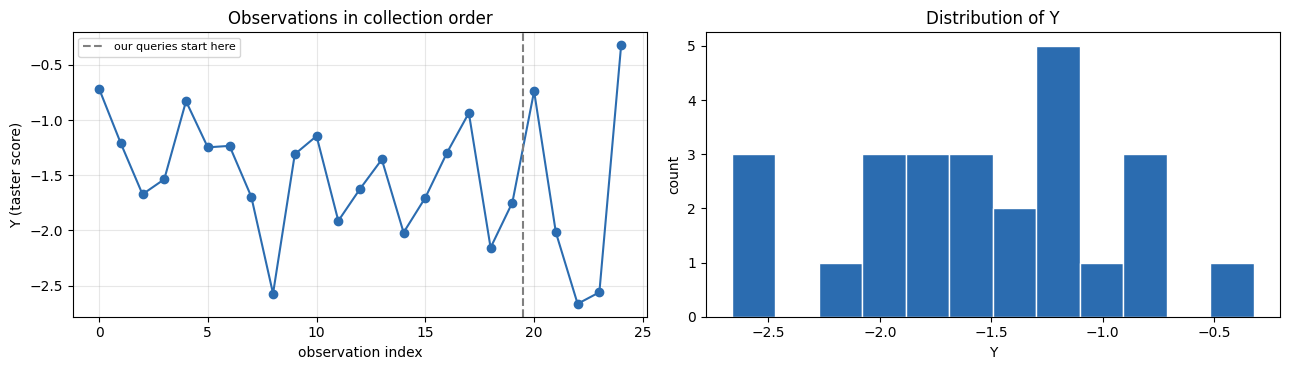

In [3]:
# Left  : scores in collection order, our five queries right of the line
# Right : how the scores are distributed

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y (taster score)")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y, bins=12, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y")

plt.tight_layout()
plt.show()

## 2. No Y transform

**Y spans −2.66 to −0.32 — a compact 3.7× range on a consistent scale.**

Unlike Functions 4 and 5, which had extreme ranges requiring log transforms,
the GP can fit this surface uniformly with no preprocessing at all. Maximising
Y directly brings the score closest to zero.

Stating this explicitly matters rather than passing over it in silence. Half
the functions in this project needed a transform, and it would be easy to apply
one here out of habit. Every transform changes the shape of the surface the GP
fits, and therefore which regions the acquisition function favours — so
applying one without cause does harm rather than good.

In [4]:
# -----------------------------------------------------------------
#  NO Y TRANSFORM
#
#  Y spans -2.66 to -0.32, a compact 3.7x range on a consistent
#  scale. The GP fits this range uniformly without distortion.
# -----------------------------------------------------------------

print(f"Y range  : [{Y.min():.6f},  {Y.max():.6f}]")
print(f"Ratio    : {abs(Y.min() / Y.max()):.1f}x")
print("\nNo transform applied - the scale is already GP-friendly.")

Y range  : [-2.663826,  -0.322692]
Ratio    : 8.3x

No transform applied - the scale is already GP-friendly.


## 3. Kernel

`ConstantKernel × Matérn(ν=5/2) + WhiteKernel`

| Component | Setting | Role |
|---|---|---|
| `ConstantKernel` | bounds (1e-3, 1e3) | Learns overall signal amplitude. |
| `Matérn(ν=2.5)` | — | The recipe surface is smooth: ingredient combinations interact continuously with no sharp discontinuities. |
| `length_scale` | 0.3, bounds **(0.05, 2.0)** | Lower bound raised from 0.01 — see the changelog. |
| `WhiteKernel` | 0.05, bounds (1e-6, 1.0) | Expert taster scoring is subjective but consistent within a narrow band. Lower than Function 4's 1.0 because these values are tight and well-behaved. |

### What changed after round 5, and why

Round 5 produced a large improvement, and the configuration was tightened in
response:

| Setting | Before | After | Reason |
|---|---|---|---|
| ξ | 0.05 | **0.01** | A new best was found — exploit tightly around it. |
| Grid | 12⁵ | **15⁵** | Finer resolution near the new peak, 759,375 candidates. |
| `length_scale` lower bound | 0.01 | **0.05** | Prevents the GP overfitting to the new concentrated cluster. |
| `WhiteKernel` | 0.05 | **0.05** | Unchanged — the scale is still compact. |

This is the same adaptive response used on Function 5, and those are the two
functions where the settings were revised in light of results rather than fixed
at the start.

In [5]:
# -----------------------------------------------------------------
#  KERNEL
# -----------------------------------------------------------------
kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),      # overall signal amplitude
    )
    * Matern(
        nu=2.5,                                 # smooth ingredient surface
        length_scale=0.3,
        length_scale_bounds=(0.05, 2.0),        # floor raised from 0.01
    )
    + WhiteKernel(
        noise_level=0.05,                       # subjective taster noise
        noise_level_bounds=(1e-6, 1.0),
    )
)

# -----------------------------------------------------------------
#  GP MODEL
# -----------------------------------------------------------------
xi = 0.01      # tight exploitation - a new best was found in round 5

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=True,
    random_state=42,
)
model.fit(X, Y)

print(f"Optimised kernel:\n  {model.kernel_}")

fitted_ls    = model.kernel_.k1.k2.length_scale
fitted_noise = model.kernel_.k2.noise_level
print(f"\n  fitted length_scale : {fitted_ls:.4g}   (started at 0.3)")
print(f"  fitted noise_level  : {fitted_noise:.4g}   (started at 0.05)")

if fitted_ls <= 0.05 * 1.01:
    print("\n  NOTE: length_scale is at its LOWER BOUND of 0.05.")
    print("  The model wants sharper variation than the kernel allows -")
    print("  which is exactly what raising the floor was meant to prevent.")

Optimised kernel:
  1.65**2 * Matern(length_scale=1.11, nu=2.5) + WhiteKernel(noise_level=1e-06)

  fitted length_scale : 1.108   (started at 0.3)
  fitted noise_level  : 1e-06   (started at 0.05)


## 4. Does the model actually work?

Leave-one-out cross-validation: hide one observation, refit on the rest,
predict the hidden point, repeat for all 25.

R² of 1.0 is perfect, 0.0 is no better than always predicting the average, and
below 0.0 is worse than that.

This matters here because 25 points in five dimensions is thin. Whether the
model has learned anything usable is an open question, not an assumption.

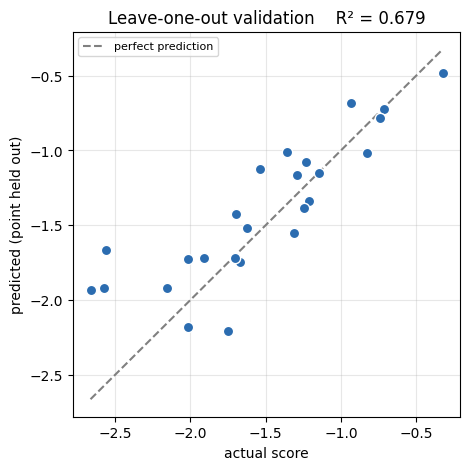

R² = 0.679

The model predicts held-out points reasonably well.


In [6]:
# -----------------------------------------------------------------
#  LEAVE-ONE-OUT VALIDATION
# -----------------------------------------------------------------
predicted = np.empty(len(Y))

for train_idx, test_idx in LeaveOneOut().split(X):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(nu=2.5, length_scale=0.3, length_scale_bounds=(0.05, 2.0))
         + WhiteKernel(0.05, (1e-6, 1.0)))
    g = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3,
                                 normalize_y=True, random_state=42)
    g.fit(X[train_idx], Y[train_idx])
    predicted[test_idx] = g.predict(X[test_idx])

residuals = Y - predicted
r2 = 1 - (residuals ** 2).sum() / ((Y - Y.mean()) ** 2).sum()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y, predicted, s=55, c="#2b6cb0", edgecolors="white", zorder=3)
lims = [min(Y.min(), predicted.min()), max(Y.max(), predicted.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect prediction")
ax.set_xlabel("actual score")
ax.set_ylabel("predicted (point held out)")
ax.set_title(f"Leave-one-out validation    R² = {r2:.3f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"R² = {r2:.3f}")
if r2 >= 0.6:
    print("\nThe model predicts held-out points reasonably well.")
elif r2 >= 0.3:
    print("\nModerate. The model has learned real structure but is not precise.")
else:
    print("\nWeak. Treat the model's suggestions with caution.")

## 5. Prediction grid and Expected Improvement

EI(x) = (μ(x) − Y_best − ξ) · Φ(Z) + σ(x) · φ(Z)

**ξ = 0.01** — tight exploitation, lowered from 0.05 after round 5 found a
clear new best.

The original ξ = 0.05 was chosen because the problem is not described as having
many local optima, unlike Function 4's warehouse surface. There was no reason
to push exploration hard, so a moderate setting was used. After round 5 that
was tightened further.

The grid is 15⁵ = 759,375 candidate points, raised from 12⁵. Five dimensions
force a coarser grid per axis than the 4D functions — 15 steps per ingredient
rather than 30 — which is a real limitation: the resolution along any single
ingredient is about 0.07.

In [7]:
# -----------------------------------------------------------------
#  5D PREDICTION GRID  (15^5 = 759,375 candidates)
# -----------------------------------------------------------------
n_grid = 15
x_vals = np.linspace(0, 1, n_grid)
g      = np.meshgrid(x_vals, x_vals, x_vals, x_vals, x_vals, indexing="ij")
X_grid = np.column_stack([gi.ravel() for gi in g])

print(f"Grid size  : {len(X_grid):,} points")
print(f"Resolution : {1 / (n_grid - 1):.4f} per ingredient")

post_mean, post_std = model.predict(X_grid, return_std=True)


# -----------------------------------------------------------------
#  EXPECTED IMPROVEMENT
# -----------------------------------------------------------------
Y_best = Y.max()


def expected_improvement(mu, sigma, y_best, xi=0.01):
    improvement = mu - y_best - xi

    # Where sigma is effectively zero, Z would divide by zero. Set it to 0.0
    # and zero the resulting EI: a point with no uncertainty offers no
    # possibility of a surprise.
    Z  = np.where(sigma > 1e-9, improvement / sigma, 0.0)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei


ei_values = expected_improvement(post_mean, post_std, Y_best, xi)


# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
best_idx     = np.argmax(ei_values)
x_next       = X_grid[best_idx]
best_obs_idx = np.argmax(Y)

print(f"\nCurrent best Y        : {Y_best:.6f}")
print(f"  found in round      : {week[best_obs_idx]}")
for name, v in zip(INGREDIENTS, X[best_obs_idx]):
    print(f"    {name:<8}{v:.4f}")

print(f"\nNext recipe to try    :")
for name, v in zip(INGREDIENTS, x_next):
    print(f"    {name:<8}{v:.4f}")
print(f"\nMax EI value          : {ei_values[best_idx]:.6f}")
print(f"Distance from current best: "
      f"{np.linalg.norm(x_next - X[best_obs_idx]):.4f}")

Grid size  : 759,375 points
Resolution : 0.0714 per ingredient



Current best Y        : -0.322692
  found in round      : 5
    flour   0.3636
    sugar   0.3636
    eggs    0.4545
    butter  0.8182
    milk    0.0909

Next recipe to try    :
    flour   0.2857
    sugar   0.1429
    eggs    0.7143
    butter  1.0000
    milk    0.0000

Max EI value          : 0.042025
Distance from current best: 0.4045


## 6. Visualisation

Ten pairwise slices across two figures, three rows each (GP mean, uncertainty,
EI). In every panel the other three ingredients are held at the next sample's
values, shown in the panel title.

Ingredient names are used directly as axis labels so the plots are immediately
interpretable — `flour`–`butter` rather than `x1`–`x4`.

A caveat on reading these, and it bites harder in five dimensions than in four:
the white dots are **all** observations projected onto the plane, including
ones whose three fixed coordinates are nowhere near the slice. A point can look
adjacent to the star while being a completely different recipe.

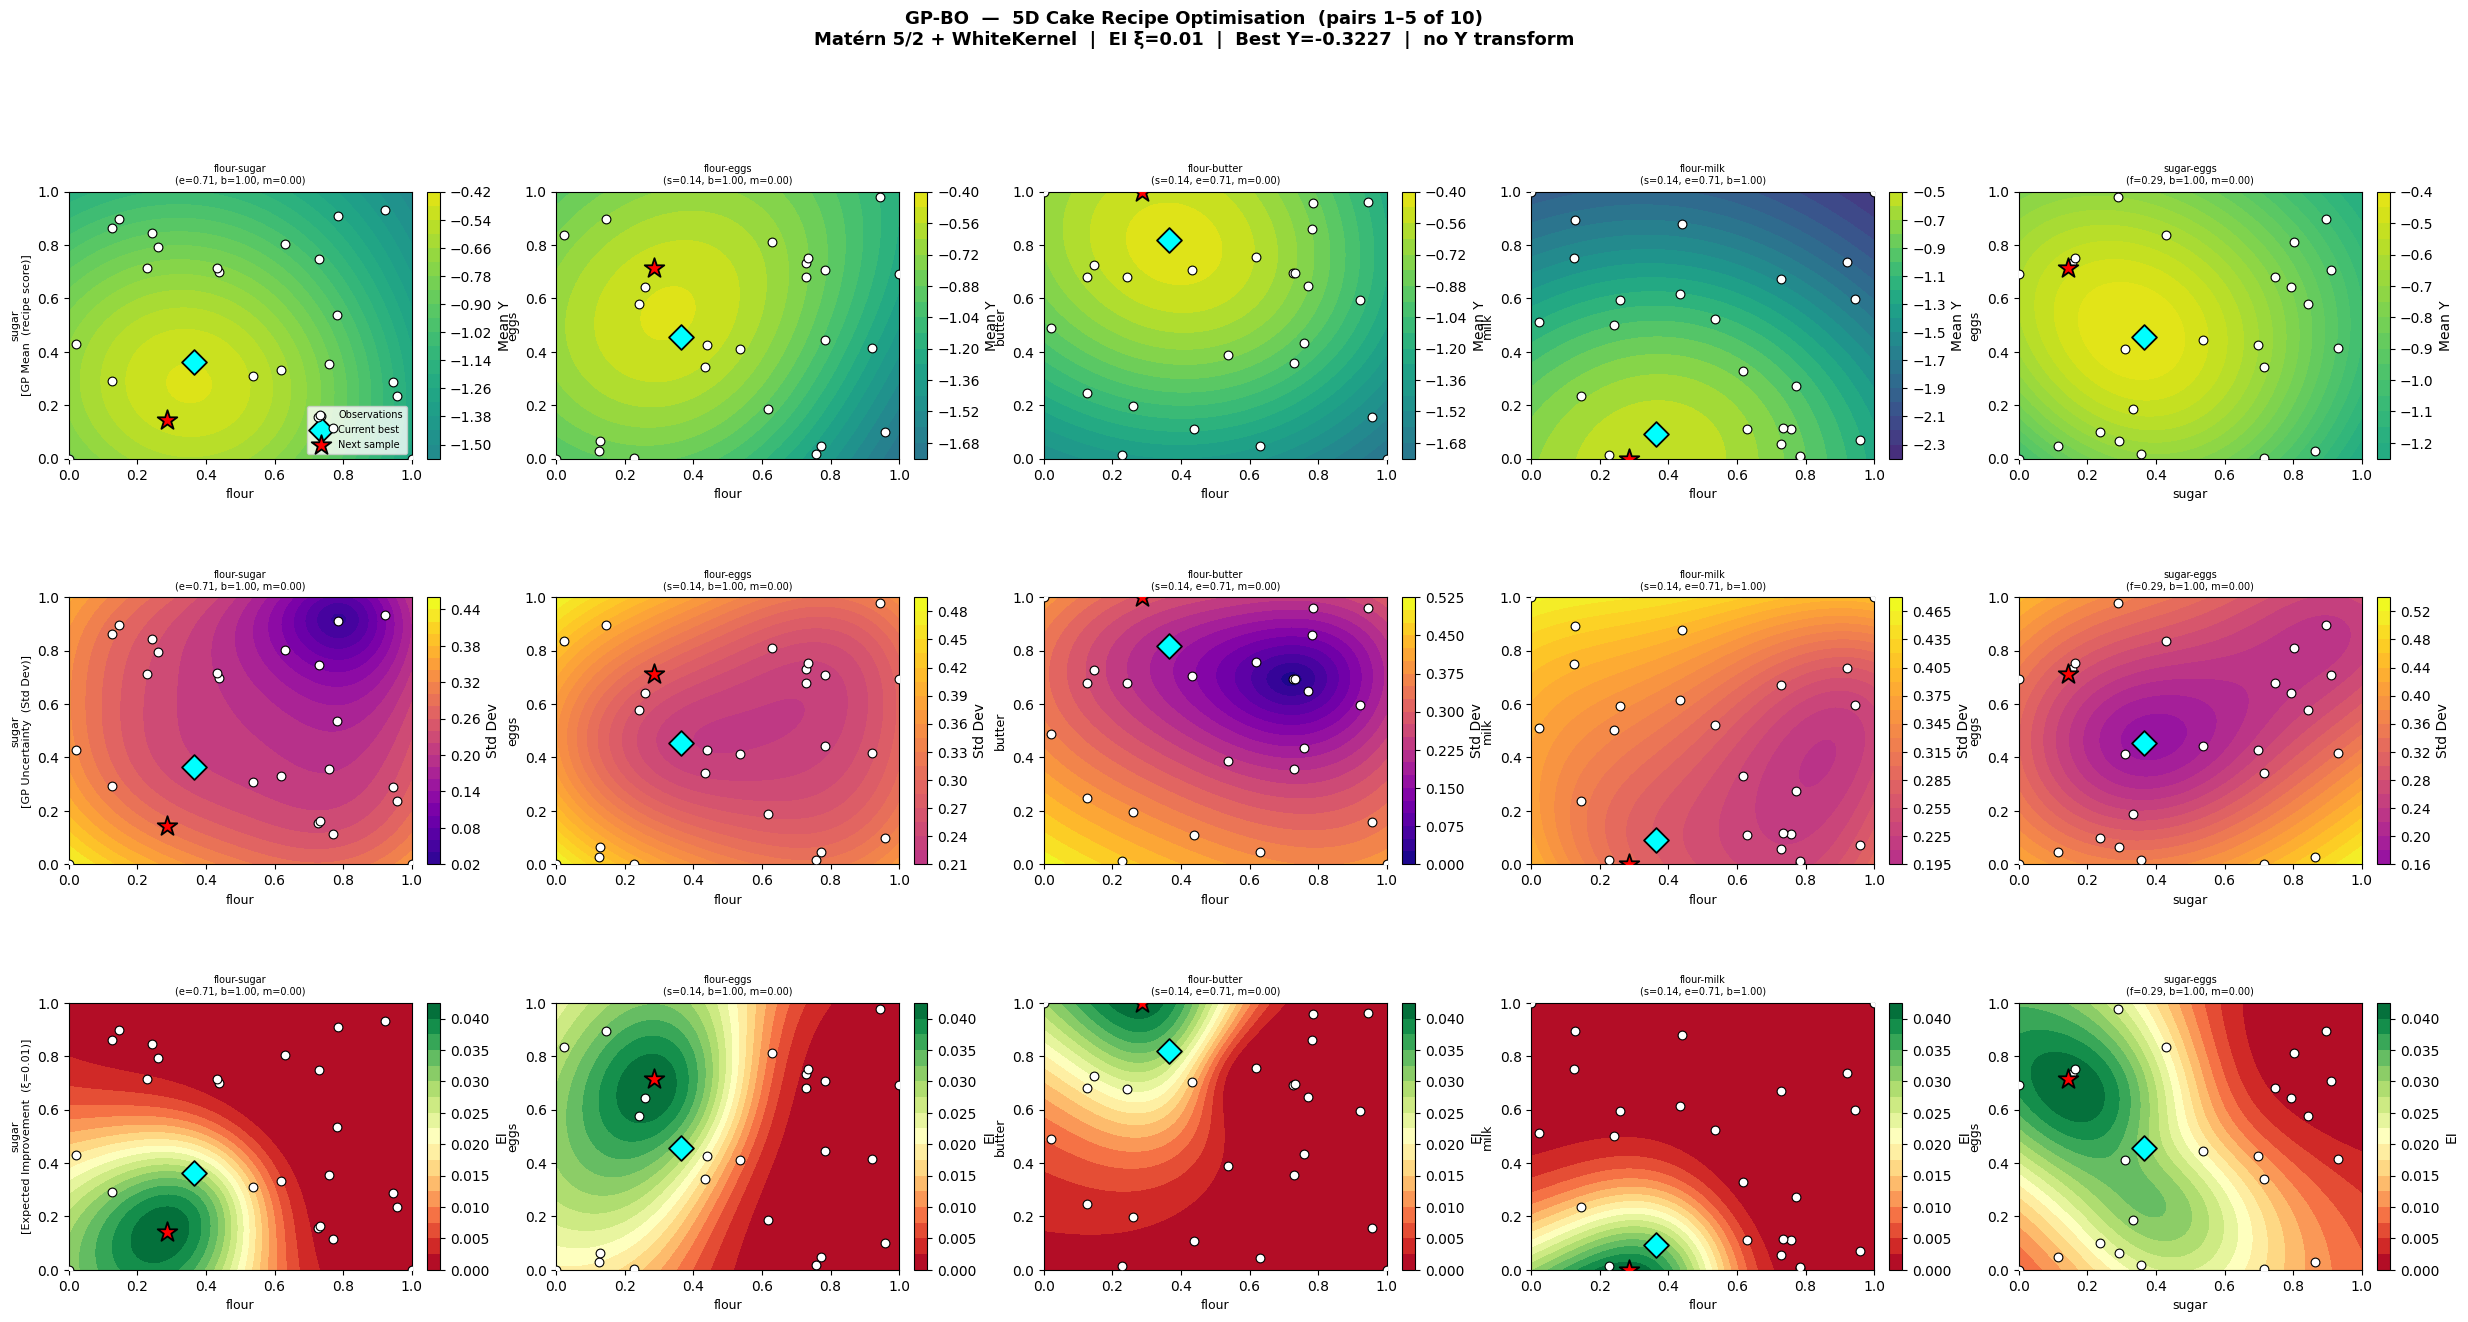

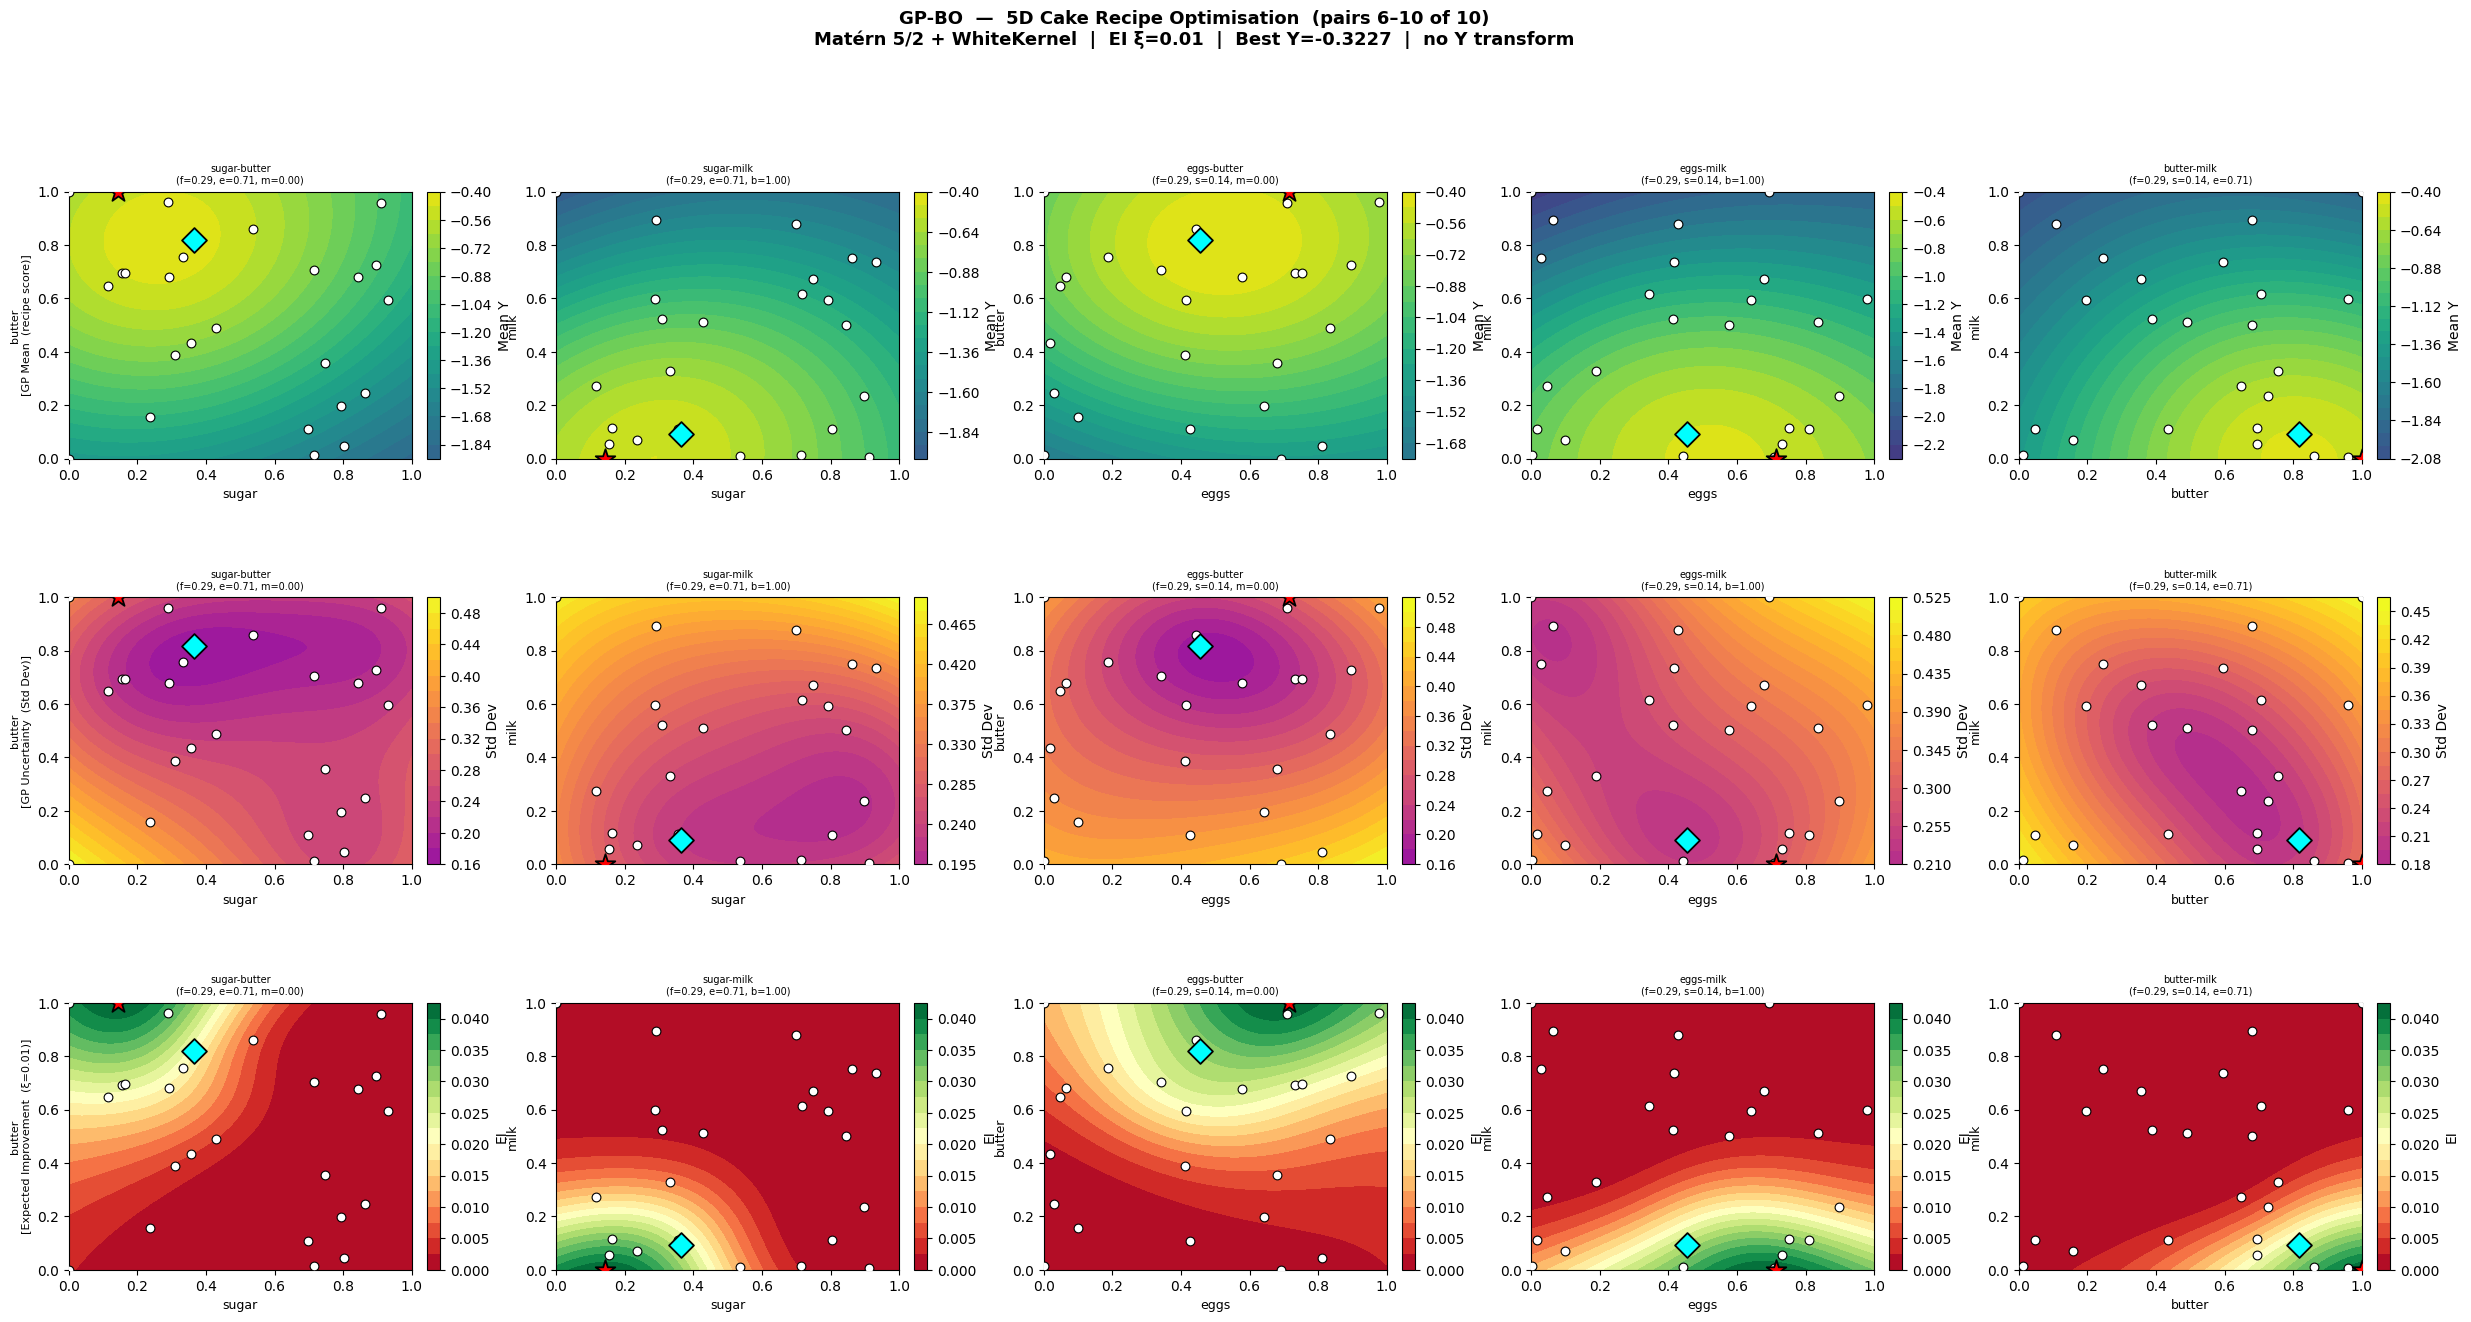

In [8]:
# -----------------------------------------------------------------
#  VISUALISATION — C(5,2) = 10 pairwise slices, 2 figures
# -----------------------------------------------------------------
n_slice     = 80
s_vals      = np.linspace(0, 1, n_slice)
S1, S2      = np.meshgrid(s_vals, s_vals)
axis_names  = INGREDIENTS
short_names = ["f", "s", "e", "b", "m"]
PAIRS       = list(combinations(range(5), 2))      # 10 pairs

ROW_LABELS = [
    "GP Mean  (recipe score)",
    "GP Uncertainty  (Std Dev)",
    f"Expected Improvement  (\u03be={xi})",
]

for fig_idx, pair_slice in enumerate([PAIRS[:5], PAIRS[5:]]):
    fig = plt.figure(figsize=(30, 14))
    fig.suptitle(
        f"GP-BO  —  5D Cake Recipe Optimisation  "
        f"(pairs {fig_idx*5+1}\u2013{fig_idx*5+len(pair_slice)} of 10)\n"
        f"Mat\u00e9rn 5/2 + WhiteKernel  |  EI \u03be={xi}  |  "
        f"Best Y={Y_best:.4f}  |  no Y transform",
        fontsize=13, fontweight="bold", y=1.01,
    )
    gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.52, wspace=0.30)

    for col, (ax_a, ax_b) in enumerate(pair_slice):

        fixed_axes = [i for i in range(5) if i not in (ax_a, ax_b)]
        title_fix  = ", ".join(
            f"{short_names[i]}={x_next[i]:.2f}" for i in fixed_axes
        )

        for row in range(3):
            ax = fig.add_subplot(gs[row, col])

            grid          = np.tile(x_next, (n_slice ** 2, 1))
            grid[:, ax_a] = S1.ravel()
            grid[:, ax_b] = S2.ravel()

            mu_sl, std_sl = model.predict(grid, return_std=True)
            ei_sl = expected_improvement(mu_sl, std_sl, Y_best, xi)

            if row == 0:
                Z, cmap    = mu_sl.reshape(n_slice, n_slice), "viridis"
                vmin, vmax = Y.min(), Y.max()
                cb_label   = "Mean Y"
            elif row == 1:
                Z, cmap    = std_sl.reshape(n_slice, n_slice), "plasma"
                vmin, vmax = 0, std_sl.max()
                cb_label   = "Std Dev"
            else:
                Z, cmap    = ei_sl.reshape(n_slice, n_slice), "RdYlGn"
                vmin, vmax = 0, max(ei_sl.max(), 1e-9)
                cb_label   = "EI"

            cf = ax.contourf(S1, S2, Z, levels=20, cmap=cmap,
                             vmin=vmin, vmax=vmax)

            ax.scatter(X[:, ax_a], X[:, ax_b], c="white", s=40,
                       edgecolors="black", linewidths=0.8, zorder=10,
                       label="Observations")
            ax.scatter(X[best_obs_idx, ax_a], X[best_obs_idx, ax_b],
                       c="cyan", s=160, marker="D", edgecolors="black",
                       linewidths=1.3, zorder=11, label="Current best")
            ax.scatter(x_next[ax_a], x_next[ax_b], c="red", s=220,
                       marker="*", edgecolors="black", linewidths=1.3,
                       zorder=12, label="Next sample")

            ax.set_xlabel(axis_names[ax_a], fontsize=9)
            ax.set_title(f"{axis_names[ax_a]}-{axis_names[ax_b]}"
                         f"\n({title_fix})", fontsize=7)

            if col == 0:
                ax.set_ylabel(f"{axis_names[ax_b]}\n[{ROW_LABELS[row]}]",
                              fontsize=8)
            else:
                ax.set_ylabel(axis_names[ax_b], fontsize=9)

            plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label=cb_label)

            if row == 0 and col == 0 and fig_idx == 0:
                ax.legend(fontsize=7, loc="lower right")

    plt.show()

## 7. Round-by-round review

Flat for four rounds, then a large gain in round 5: **−0.714 → −0.323**, more
than halving the score.

| Round | Recipe (f, s, e, b, m) | Y | Best after | Improved |
|---|---|---|---|---|
| 1 | [0.734, 0.162, 0.753, 0.695, 0.115] | −0.739 | −0.714 | no |
| 2 | [0.227, 0.714, 0.002, 0.013, 0.014] | −2.018 | −0.714 | no |
| 3 | [1.000, 0.000, 0.692, 0.000, 1.000] | −2.664 | −0.714 | no |
| 4 | [0.000, 0.000, 0.000, 1.000, 1.000] | −2.560 | −0.714 | no |
| 5 | [0.364, 0.364, 0.455, 0.818, 0.091] | **−0.323** | **−0.323** | **yes** |

Rounds 2, 3 and 4 sampled extreme recipes — round 3 used maximum flour with
zero sugar and zero butter, round 4 used no flour, sugar or eggs at all. All
three scored badly, as you would expect of a cake made that way.

### A hypothesis that was overturned

After round 1, the analysis concluded:

> *low sugar and very low milk appear to be key drivers of the best score so
> far*

That was drawn from the two best recipes at the time, both of which had sugar
near 0.15 and milk near 0.06–0.12.

Round 5's winner has **sugar at 0.364** — more than double — and butter at
0.818 rather than 0.695. The pattern that actually holds up is:

| Ingredient | Round 1 best | Round 5 best | Verdict |
|---|---|---|---|
| flour | 0.728 | 0.364 | changed a lot |
| sugar | 0.154 | 0.364 | **hypothesis wrong** — more than doubled |
| eggs | 0.733 | 0.455 | changed a lot |
| butter | 0.694 | 0.818 | high in both, higher now |
| milk | 0.056 | 0.091 | **low in both — the one driver that survives** |

Only **low milk** survives as a consistent signal. The "low sugar" conclusion
was a local pattern in two nearby points, not a property of the surface.

This is worth recording plainly. The earlier reading was a reasonable
inference from the data available, and it was wrong — and the model found the
better region without it. Where a search succeeds despite a mistaken
hypothesis, saying so is more useful than quietly updating the story.

**Two cautions:**

1. **One improvement in five rounds is thin evidence.** With 25 points in five
   dimensions, round 5's result could be a genuinely better region or a lucky
   sample. A follow-up query near [0.364, 0.364, 0.455, 0.818, 0.091] would
   settle it, and is more informative than moving on.

2. **The grid is coarse.** At 15 steps per ingredient the resolution is about
   0.07, which is larger than the difference between several of the recipes
   above. The true optimum may sit between grid points.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    prev_best = Y[week < r].max()
    row = {"round": r}
    for name, v in zip(INGREDIENTS, X[i]):
        row[name] = round(float(v), 3)
    row["Y"]          = round(float(Y[i]), 4)
    row["best after"] = round(float(Y[week <= r].max()), 4)
    row["improved"]   = "yes" if Y[i] > prev_best else "no"
    rows.append(row)

pd.DataFrame(rows)

,round,flour,sugar,eggs,butter,milk,Y,best after,improved
0,1,0.734,0.162,0.752,0.695,0.115,-0.7391,-0.7143,no
1,2,0.227,0.714,0.002,0.013,0.014,-2.0175,-0.7143,no
2,3,1.000,0.000,0.692,0.000,1.000,-2.6638,-0.7143,no
3,4,0.000,0.000,0.000,1.000,1.000,-2.5597,-0.7143,no
4,5,0.364,0.364,0.455,0.818,0.091,-0.3227,-0.3227,yes


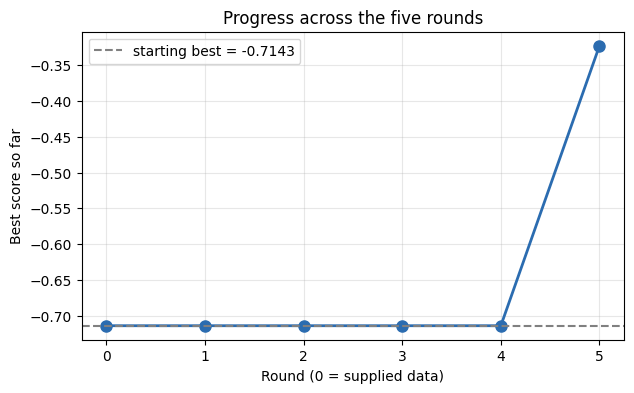

In [10]:
# Best score so far, after each round. The four flat rounds followed by a
# single large jump is the shape of this function's whole trajectory.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.4f}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best score so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [11]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
start_best = Y[week == 0].max()

print("=" * 65)
print("Summary — Cake Recipe Optimisation 5D")
print("=" * 65)
print(f"  Total observations        : {len(X)}")
print(f"  Best Y so far             : {Y[best_obs_idx]:.6f}")
print(f"  Found in round            : {week[best_obs_idx]}")
print(f"  Best recipe               :")
for name, v in zip(INGREDIENTS, X[best_obs_idx]):
    print(f"    {name:<8}{v:.4f}")
print(f"  Starting best             : {start_best:.6f}")
print(f"  Improvement               : "
      f"{(Y.max() - start_best) / abs(start_best) * 100:+.1f}%")
print(f"  Y transform               : None (compact scale)")
print(f"  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel")
print(f"  Fitted length_scale       : {fitted_ls:.4g}")
print(f"  Fitted noise_level        : {fitted_noise:.4g}")
print(f"  Model quality (R2)        : {r2:.3f}")
print(f"  EI xi parameter           : {xi}  (tight exploitation)")
print(f"  Grid resolution           : {n_grid}^5 = {n_grid**5:,} points")
print(f"  Next recipe to try        :")
for name, v in zip(INGREDIENTS, x_next):
    print(f"    {name:<8}{v:.4f}")
print(f"  Max EI value              : {ei_values[best_idx]:.6f}")
print("=" * 65)

Summary — Cake Recipe Optimisation 5D
  Total observations        : 25
  Best Y so far             : -0.322692
  Found in round            : 5
  Best recipe               :
    flour   0.3636
    sugar   0.3636
    eggs    0.4545
    butter  0.8182
    milk    0.0909
  Starting best             : -0.714265
  Improvement               : +54.8%
  Y transform               : None (compact scale)
  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel
  Fitted length_scale       : 1.108
  Fitted noise_level        : 1e-06
  Model quality (R2)        : 0.679
  EI xi parameter           : 0.01  (tight exploitation)
  Grid resolution           : 15^5 = 759,375 points
  Next recipe to try        :
    flour   0.2857
    sugar   0.1429
    eggs    0.7143
    butter  1.0000
    milk    0.0000
  Max EI value              : 0.042025


---

See `MODEL_CARD.md` for how this function compares with the other seven and for
the full list of assumptions and limitations, and `DATASHEET.md` for known gaps
and biases in the data.